# Evaluate performance of AutoEncoder models

In [1]:
import os
import sys

CURRENT_DIR = os.path.abspath("")

# add parent dir to python path
sys.path.append(os.path.join(CURRENT_DIR, *[".."] * 2))

In [2]:
import random
from itertools import combinations
from typing import Any

import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist
from tqdm.auto import tqdm

from src.v2.api.services.embed_properties import embed_properties
from src.v2.api.services.get_scores import _load_data_cached
from src.v2.api.services.load_leads_df import load_leads_data_db
from src.v2.autoencoder.feature_specs import get_feature_columns
from src.v2.config import get_config

In [3]:
leads_df = await load_leads_data_db()
leads_properties_df = await _load_data_cached(ids=leads_df["property_id"].unique().tolist())

2025-05-08 13:40:44.086 | INFO     | src.v2.utils.cache_utils:get_or_create_cached_df:62 - Loading data for 46206 items with caching
2025-05-08 13:40:44.123 | DEBUG    | src.v2.utils.cache_utils:get_or_create_cached_df:74 - Retrieving 46206 items from cache
2025-05-08 13:41:07.829 | DEBUG    | src.v2.utils.cache_utils:get_or_create_cached_df:84 - Found 46206 items in cache, need to load 0 items


In [4]:
print(get_config().properties_embedding_model.mlflow_artifact_path)

mlflow-artifacts:/6/6737a0bcd14b49e5a301a15299356ee2/artifacts/properties_autoencoder_apartments-epoch=28-val_loss=0.0929/properties_autoencoder_apartments-epoch=28-val_loss=0.0929.ckpt


In [5]:
leads_properties_df = embed_properties(leads_properties_df)

2025-05-08 13:41:11.742 | DEBUG    | src.v2.api.services.embed_properties:_load_model:14 - Loading model from mlflow-artifacts:/6/6737a0bcd14b49e5a301a15299356ee2/artifacts/properties_autoencoder_apartments-epoch=28-val_loss=0.0929/properties_autoencoder_apartments-epoch=28-val_loss=0.0929.ckpt


In [6]:
# get dot product of all properties
sim_matrix = np.dot(
    np.array(leads_properties_df["embeddings"].tolist()),
    np.array(leads_properties_df["embeddings"].tolist()).T,
)

In [7]:
sim_matrix.shape

(46206, 46206)

Sampled 100000 indices from 2134994436
Sampled 100000 values


Text(0, 0.5, 'Frequency')

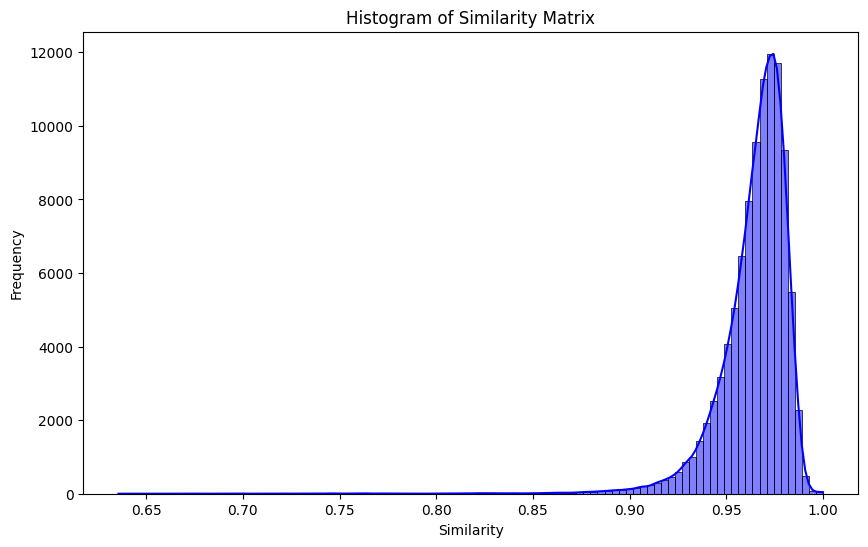

In [8]:
# plot a histogram of the similarity matrix
import matplotlib.pyplot as plt
import seaborn as sns

# but first sample 1000000 values from the matrix since it is too large
sample_size = 100000
flattened_sim_matrix = sim_matrix.flatten()
sample_indices = random.sample(
    range(len(flattened_sim_matrix)), sample_size
)  # random.sample(range(len(flattened_sim_matrix)), sample_size)
print(f"Sampled {len(sample_indices)} indices from {len(flattened_sim_matrix)}")
samples = flattened_sim_matrix[sample_indices]
print(f"Sampled {len(samples)} values")
plt.figure(figsize=(10, 6))
sns.histplot(
    samples,
    bins=100,
    kde=True,
    color='blue',
)
plt.title("Histogram of Similarity Matrix")
plt.xlabel("Similarity")
plt.ylabel("Frequency")

In [ ]:
np.unravel_index(min_pair, sim_matrix.shape)
leads_properties_df.iloc[list(np.unravel_index(min_pair, sim_matrix.shape))][["property_id", "offer_id", "type_id", "city_name", "area", "price", "price_m2"]]

## Cluster the data

In [ ]:
# use t-SNE to reduce the dimensionality of the embeddings
from sklearn.manifold import TSNE

embeddings = np.array(leads_properties_df["embeddings"].tolist())
tsne = TSNE(n_components=2, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings)

In [ ]:
import plotly.express as px
import plotly.graph_objects as go

# Create a DataFrame for the visualization with additional parameters for hover info
viz_df = pd.DataFrame(
    {
        "x": embeddings_2d[:, 0],
        "y": embeddings_2d[:, 1],
        "city_name": leads_properties_df["city_name"],
        "property_id": leads_properties_df["property_id"],
        "price_m2": leads_properties_df["price_m2"],
        "price": leads_properties_df["price"],
        "area": leads_properties_df["area"],
        "rooms": leads_properties_df["rooms"],
        "floor": leads_properties_df["floor"],
        "offer_id": leads_properties_df["offer_id"],
        "lat": leads_properties_df["lat"],
        "lon": leads_properties_df["lon"], 
    }
)

# Map categorical city names to numeric codes for coloring
city_categories = viz_df["city_name"].astype("category")
city_codes = city_categories.cat.codes
viz_df["city_code"] = city_codes

# Get list of unique cities and count of properties per city
city_counts = leads_properties_df["city_name"].value_counts().sort_values(ascending=False)
unique_cities = city_categories.cat.categories.tolist()
num_cities = len(unique_cities)

# Show stats about the cities
print(f"Number of unique cities: {num_cities}")
print("\nTop 10 cities by frequency:")
print(city_counts.head(10))

# Create an interactive plot with Plotly
# Get the top 15 cities for legibility in the color scale
top_cities = leads_properties_df["city_name"].value_counts().head(15).index.tolist()

# Create a custom color mapping for top cities
viz_df["city_marker"] = "Other"
for city in top_cities:
    viz_df.loc[viz_df["city_name"] == city, "city_marker"] = city

# Create the interactive scatter plot with hover info
fig = px.scatter(
    viz_df,
    x="x",
    y="y",
    color="city_marker",
    hover_data={
        "property_id": True,
        "city_name": True,
        "price_m2": True,
        "price": True,
        "area": True,
        "rooms": True,
        "floor": True,
        "offer_id": True,
        "lat": True,
        "lon": True,
        "x": False,  # Hide x and y coordinates in hover info
        "y": False,
    },
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Interactive t-SNE Visualization of Property Embeddings",
)

# Customize the layout for better readability
fig.update_layout(
    width=1000,
    height=800,
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    legend_title="City",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="right", x=1.15),
)

# Add zoom, pan, and other interactive features
fig.update_layout(dragmode="zoom", hovermode="closest", template="plotly_white")

# Display the interactive plot
fig.show()

In [ ]:
import pandas as pd
import plotly.express as px

# Create a DataFrame for the visualization with additional parameters for hover info
viz_df = pd.DataFrame(
    {
        "x": embeddings_2d[:, 0],
        "y": embeddings_2d[:, 1],
        "house_type": leads_properties_df["house_type"],
        "flat_type": leads_properties_df["flat_type"],
        "type_id": leads_properties_df["type_id"],
        "city_name": leads_properties_df["city_name"],
        "property_id": leads_properties_df["property_id"],
        "price_m2": leads_properties_df["price_m2"],
        "price": leads_properties_df["price"],
        "area": leads_properties_df["area"],
        "area_log": np.log1p(leads_properties_df["area"]),
        "price_log": np.log1p(leads_properties_df["price"]),
        "price_m2_log": np.log1p(leads_properties_df["price_m2"]),
        "rooms": leads_properties_df["rooms"],
        "floor": leads_properties_df["floor"],
        "offer_id": leads_properties_df["offer_id"],
        "lat": leads_properties_df["lat"],
        "lon": leads_properties_df["lon"],
    }
)

# Create the interactive scatter plot with hover info
fig = px.scatter(
    viz_df,
    x="x",
    y="y",
    color="floor",
    hover_data={
        "property_id": True,
        "offer_id": True,
        "city_name": True,
        "price_m2": True,
        "price": True,
        "area": True,
        "rooms": True,
        "floor": True,
        "lat": True,
        "lon": True,
        "x": False,  # Hide x and y coordinates in hover info
        "y": False,
    },
    opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Bold,
    title="Interactive t-SNE Visualization of Property Embeddings",
)

# Customize the layout for better readability
fig.update_layout(
    width=1000,
    height=800,
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    legend_title="Property Type",
    legend=dict(orientation="v", yanchor="top", y=1, xanchor="right", x=1.15),
)

# Add zoom, pan, and other interactive features
fig.update_layout(dragmode="zoom", hovermode="closest", template="plotly_white")

# Display the interactive plot
fig.show()

### Visualization: Color by Geographic Coordinates

In [ ]:
# Create a visualization with properties colored by their geographic coordinates
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

# Create versions of the visualization colored by latitude and longitude
# Create subplots for side-by-side comparison
from plotly.subplots import make_subplots

# Create a figure with 1 row and 2 columns for side-by-side comparison
fig = make_subplots(
    rows=1, cols=2, subplot_titles=("Colored by Latitude", "Colored by Longitude"), horizontal_spacing=0.08
)

# Add scatter trace for latitude coloring
lat_scatter = go.Scatter(
    x=viz_df["x"],
    y=viz_df["y"],
    mode="markers",
    marker=dict(
        size=6, color=viz_df["lat"], colorscale="Viridis", colorbar=dict(title="Latitude", x=0.45), showscale=True
    ),
    hovertemplate=(
        "<b>Property ID:</b> %{customdata[0]}<br>"
        "<b>City:</b> %{customdata[1]}<br>"
        "<b>Lat:</b> %{customdata[2]:.4f}<br>"
        "<b>Lon:</b> %{customdata[3]:.4f}<br>"
        "<b>Price per m²:</b> %{customdata[4]:.2f} PLN<br>"
        "<b>Area:</b> %{customdata[5]:.1f} m²<br>"
        "<b>Rooms:</b> %{customdata[6]}<br>"
    ),
    customdata=np.stack(
        (
            viz_df["property_id"],
            viz_df["city_name"],
            viz_df["lat"],
            viz_df["lon"],
            viz_df["price_m2"],
            viz_df["area"],
            viz_df["rooms"],
        ),
        axis=-1,
    ),
)

# Add scatter trace for longitude coloring
lon_scatter = go.Scatter(
    x=viz_df["x"],
    y=viz_df["y"],
    mode="markers",
    marker=dict(
        size=6, color=viz_df["lon"], colorscale="Cividis", colorbar=dict(title="Longitude", x=1.0), showscale=True
    ),
    hovertemplate=(
        "<b>Property ID:</b> %{customdata[0]}<br>"
        "<b>City:</b> %{customdata[1]}<br>"
        "<b>Lat:</b> %{customdata[2]:.4f}<br>"
        "<b>Lon:</b> %{customdata[3]:.4f}<br>"
        "<b>Price per m²:</b> %{customdata[4]:.2f} PLN<br>"
        "<b>Area:</b> %{customdata[5]:.1f} m²<br>"
        "<b>Rooms:</b> %{customdata[6]}<br>"
    ),
    customdata=np.stack(
        (
            viz_df["property_id"],
            viz_df["city_name"],
            viz_df["lat"],
            viz_df["lon"],
            viz_df["price_m2"],
            viz_df["area"],
            viz_df["rooms"],
        ),
        axis=-1,
    ),
)

# Add traces to the subplot
fig.add_trace(lat_scatter, row=1, col=1)
fig.add_trace(lon_scatter, row=1, col=2)

# Update layout
fig.update_layout(
    title="Geographic Distribution of Property Embeddings in t-SNE Space",
    width=1200,
    height=600,
    template="plotly_white",
)

# Update x and y axis labels
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=1)
fig.update_xaxes(title_text="t-SNE Component 1", row=1, col=2)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=1)
fig.update_yaxes(title_text="t-SNE Component 2", row=1, col=2)

fig.show()

In [ ]:
# Create a combined visualization showing both lat and lon as different color dimensions
# Create a new figure with color encoding both latitude and longitude

# Method 1: Use a scatter plot with a custom color based on both lat and lon
# We'll normalize both lat and lon to the range [0, 1] and use them for different color channels

# Normalize latitude and longitude to [0, 1]
lat_min, lat_max = viz_df["lat"].min(), viz_df["lat"].max()
lon_min, lon_max = viz_df["lon"].min(), viz_df["lon"].max()

lat_normalized = (viz_df["lat"] - lat_min) / (lat_max - lat_min)
lon_normalized = (viz_df["lon"] - lon_min) / (lon_max - lon_min)

# Create RGB colors: Red channel from latitude, Blue channel from longitude
# This creates a color palette representing different geographic regions
colors = [
    f"rgb({int(255 * lat)}, {int(255 * (1 - lat) * lon)}, {int(255 * lon)})"
    for lat, lon in zip(lat_normalized, lon_normalized)
]

# Create figure
fig = go.Figure()

# Add markers
fig.add_trace(
    go.Scatter(
        x=viz_df["x"],
        y=viz_df["y"],
        mode="markers",
        marker=dict(size=6, color=colors, opacity=0.7),
        hovertemplate=(
            "<b>Property ID:</b> %{customdata[0]}<br>"
            "<b>City:</b> %{customdata[1]}<br>"
            "<b>Lat:</b> %{customdata[2]:.4f}<br>"
            "<b>Lon:</b> %{customdata[3]:.4f}<br>"
            "<b>Price per m²:</b> %{customdata[4]:.2f} PLN<br>"
            "<b>Area:</b> %{customdata[5]:.1f} m²<br>"
            "<b>Rooms:</b> %{customdata[6]}<br>"
        ),
        customdata=np.stack(
            (
                viz_df["property_id"],
                viz_df["city_name"],
                viz_df["lat"],
                viz_df["lon"],
                viz_df["price_m2"],
                viz_df["area"],
                viz_df["rooms"],
            ),
            axis=-1,
        ),
        name="Properties",
    )
)

# Create a separate trace for the legend reference points
# These are representative points for the corners of our color scheme
legend_x = [viz_df["x"].mean()] * 4
legend_y = [viz_df["y"].mean()] * 4

# Define some reference points for the legend (won't be visible on plot)
legend_colors = [
    "rgb(255, 0, 0)",  # High latitude (North), Low longitude (West)
    "rgb(255, 0, 255)",  # High latitude (North), High longitude (East)
    "rgb(0, 255, 0)",  # Low latitude (South), Low longitude (West)
    "rgb(0, 0, 255)",  # Low latitude (South), High longitude (East)
]

legend_labels = [
    "North-West (High Lat, Low Lon)",
    "North-East (High Lat, High Lon)",
    "South-West (Low Lat, Low Lon)",
    "South-East (Low Lat, High Lon)",
]

for i in range(4):
    # Add invisible reference points for the legend
    fig.add_trace(
        go.Scatter(
            x=[legend_x[i]],
            y=[legend_y[i]],
            mode="markers",
            marker=dict(size=10, color=legend_colors[i]),
            name=legend_labels[i],
            # Make points invisible on the actual plot
            opacity=0,
        )
    )

# Add a note about color interpretation
fig.add_annotation(
    text="Colors represent geographic position:<br>Red channel = Latitude<br>Blue channel = Longitude<br>Green = Mix of both",
    xref="paper",
    yref="paper",
    x=0.01,
    y=0.99,
    showarrow=False,
    bgcolor="rgba(255, 255, 255, 0.8)",
    bordercolor="black",
    borderwidth=1,
    borderpad=4,
    align="left",
)

# Update layout
fig.update_layout(
    title="Property Embeddings with Geographic Color Mapping",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    legend_title="Geographic Position",
    width=1000,
    height=800,
    template="plotly_white",
    legend=dict(orientation="v", yanchor="top", y=0.99, xanchor="left", x=1.01, bordercolor="Black", borderwidth=1),
)

fig.show()

## Evaluate Model Performance: User Lead Similarity Analysis

Here we'll test the hypothesis that users tend to lead on similar properties. If this is true, a good embedding model should place properties that the same user has led on closer together in the embedding space.

We'll calculate:
1. Average pairwise distance between properties led on by the same user
2. Compare this across different models to identify which model better captures user preferences

In [ ]:
models_to_test = {
    "model_1": {
        "path": "mlflow-artifacts:/6/6737a0bcd14b49e5a301a15299356ee2/artifacts/properties_autoencoder_apartments-epoch=28-val_loss=0.0929/properties_autoencoder_apartments-epoch=28-val_loss=0.0929.ckpt",
        "model_type": "autoencoder",
        "model_name": "properties_autoencoder_apartments",
        "feature_specs": "apartments",
        "description": "Trained on apartments with apartments-only features",
    },
    "model_2": {
        "path": "mlflow-artifacts:/7/6d659ed2843846d8a9b29f9b66a39f4a/artifacts/visible_properties_autoencoder-epoch=40-val_loss=0.0704/visible_properties_autoencoder-epoch=40-val_loss=0.0704.ckpt",
        "model_type": "autoencoder",
        "model_name": "visible_properties_autoencoder",
        "feature_specs": "apartments",
        "description": "Trained on all visible properties but with apartments-only features (it was a mistake)",
    },
    "model_3": {
        "path": "mlflow-artifacts:/7/22170ca88b554706b50eb1719a07f30d/artifacts/epoch=50-val_loss=0.0485/epoch=50-val_loss=0.0485.ckpt",
        "model_type": "autoencoder",
        "model_name": "visible_properties_autoencoder_full",
        "feature_specs": "full",
        "description": "Trained on all visible properties with all features",
    },
}

In [ ]:
def calculate_user_lead_distances(
    leads_df: pd.DataFrame,
    embeddings_df: pd.DataFrame,
    normalization="none",
    reference_distances=None,
) -> tuple[pd.DataFrame, dict]:
    """
    Calculate the average distance between properties that each user has led on,
    with optional distance normalization methods.

    Args:
        leads_df: DataFrame with user lead data (must have 'algolytics_uuid' and 'property_id')
        embeddings_df: DataFrame with property embeddings (must have 'property_id' and 'embeddings')
        normalization: Type of normalization to apply:
            - 'none': Raw distances
            - 'minmax': Min-max scaling to [0,1] range
            - 'relative': Normalize by average distance in embedding space
            - 'similarity': Convert to similarity score (1 = identical, 0 = very different)
        reference_distances: Optional array of distances to use for normalization

    Returns:
        DataFrame with average distances for each user and overall average,
        Dictionary with overall stats and reference values for normalization
    """
    # Create a mapping of property_id to embeddings for faster lookup
    property_embeddings = {
        row["property_id"]: np.array(row["embeddings"]) for _, row in embeddings_df.iterrows() if "embeddings" in row
    }

    # Group leads by user
    user_leads = leads_df.groupby("algolytics_uuid")["property_id"].agg(list).to_dict()

    # Calculate global distance statistics if needed for normalization
    global_distances = None
    if normalization in ["minmax", "relative"] and reference_distances is None:
        print("Computing global distance statistics for normalization...")
        # Sample properties for global statistics calculation (using all might be too memory-intensive)
        max_sample = min(5000, len(property_embeddings))
        sampled_ids = np.random.choice(list(property_embeddings.keys()), size=max_sample, replace=False)
        sampled_embeddings = np.array([property_embeddings[pid] for pid in sampled_ids])
        global_distances = pdist(sampled_embeddings, metric="euclidean")
        print(
            f"Global stats - Mean distance: {np.mean(global_distances):.4f}, Min: {np.min(global_distances):.4f}, Max: {np.max(global_distances):.4f}"
        )
    elif reference_distances is not None:
        global_distances = reference_distances

    mean_dist = np.mean(global_distances) if global_distances is not None else None
    min_dist = np.min(global_distances) if global_distances is not None else None
    max_dist = np.max(global_distances) if global_distances is not None else None


    # Initialize results
    results = []
    all_user_distances = []

    # Calculate average distance for each user
    for user_id, property_ids in tqdm(user_leads.items(), desc="Processing users"):
        # Filter to properties that exist in our embeddings
        available_property_ids = [pid for pid in property_ids if pid in property_embeddings]

        # Skip users with fewer than 2 properties (can't calculate distance)
        if len(available_property_ids) < 2:
            continue

        # Get embeddings for this user's properties
        user_property_embeddings = np.array([property_embeddings[pid] for pid in available_property_ids])

        # Calculate pairwise distances between all properties
        distances = pdist(user_property_embeddings, metric="euclidean")

        # Store the raw distances for later use
        all_user_distances.extend(distances)

        # Apply normalization if requested
        if normalization == "minmax" and global_distances is not None:
            # Min-max scaling to [0,1] range
            distances = (distances - min_dist) / (max_dist - min_dist)
        elif normalization == "relative" and global_distances is not None:
            # Normalize by average distance in embedding space
            distances = distances / mean_dist
        elif normalization == "similarity":
            # Convert to similarity score (1 = identical, 0 = very different)
            # Using a Gaussian kernel with sigma = mean(distances)/3 as a rule of thumb
            sigma = np.mean(distances) / 3
            distances = np.exp(-(distances**2) / (2 * sigma**2))

        # Record results
        results.append(
            {
                "user_id": user_id,
                "num_properties": len(available_property_ids),
                "avg_distance": np.mean(distances),
                "median_distance": np.median(distances),
                "min_distance": np.min(distances),
                "max_distance": np.max(distances),
            }
        )

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Calculate overall statistics
    overall_stats = {
        "overall_avg_distance": results_df["avg_distance"].mean(),
        "overall_median_distance": results_df["avg_distance"].median(),
        "num_users": len(results_df),
        "normalization": normalization,
        "reference_distances": global_distances,
        "all_user_distances": np.array(all_user_distances),
    }

    return results_df, overall_stats

In [ ]:
# Test the models and compare their performance
from rich.console import Console
from rich.table import Table

console = Console()
model_results = {}

# Create a table for displaying results
table = Table(title="Embedding Model Comparison: Average User Lead Distances")
table.add_column("Model Name")
table.add_column("Overall Avg Distance", justify="right")
table.add_column("Overall Median Distance", justify="right")
table.add_column("Users Evaluated", justify="right")

for model_id, model_spec in models_to_test.items():
    print(f"Testing model: {model_id} - {model_spec['model_name']}")
    model_path = model_spec["path"]
    model_name = model_spec["model_name"]

    # Set the model path in the config
    config = get_config()
    config.properties_embedding_model.mlflow_artifact_path = model_path
    config.properties_embedding_model.feature_spec_type = model_spec["feature_specs"]

    # Reload properties with embeddings from this model
    leads_properties_df = embed_properties(leads_properties_df)

    # Calculate distances
    results_df, overall_stats = calculate_user_lead_distances(leads_df, leads_properties_df)

    # Store results
    model_results[model_id] = {
        "model_name": model_name,
        "results_df": results_df,
        "overall_stats": overall_stats,
    }

    # Add to table
    table.add_row(
        model_name,
        f"{overall_stats['overall_avg_distance']:.4f}",
        f"{overall_stats['overall_median_distance']:.4f}",
        str(overall_stats["num_users"]),
    )

# Display the table
console.print(table)

### Adding Normalized Distance Analysis

Let's now test our improved distance calculation function that addresses the scale issue:

1. **Raw Distances**: Original Euclidean distances without normalization
2. **Min-Max Normalized**: Scale distances to [0,1] range
3. **Relative Normalized**: Normalizes distances by dividing by the average distance in the embedding space
4. **Similarity Score**: Transform distances to similarity scores (1.0 = identical, 0.0 = very different)

This will allow for more meaningful comparisons between embedding models.

In [ ]:
# Test the models with different normalization methods
import matplotlib.pyplot as plt
import seaborn as sns
from rich.console import Console
from rich.table import Table

console = Console()
normalization_methods = ["none", "minmax", "relative", "similarity"]

for norm_method in normalization_methods:
    print(f"\n\n== Testing models with {norm_method} normalization ==\n")

    model_results_norm = {}
    reference_distances = None

    # Create a table for displaying results
    table = Table(title=f"Embedding Model Comparison: {norm_method.capitalize()} Distances")
    table.add_column("Model Name")
    table.add_column("Overall Avg Distance", justify="right")
    table.add_column("Overall Median Distance", justify="right")
    table.add_column("Users Evaluated", justify="right")

    for model_id, model_spec in models_to_test.items():
        print(f"Testing model: {model_id} - {model_spec['model_name']}")
        model_path = model_spec["path"]
        model_name = model_spec["model_name"]

        # Set the model path in the config
        config = get_config()
        config.properties_embedding_model.mlflow_artifact_path = model_path

        # Reload properties with embeddings from this model
        leads_properties_df = embed_properties(leads_properties_df)

        # Calculate distances with the specified normalization
        results_df, overall_stats = calculate_user_lead_distances(
            leads_df,
            leads_properties_df,
            normalization=norm_method,
            reference_distances=reference_distances,
        )

        # Store results
        model_results_norm[model_id] = {
            "model_name": model_name,
            "results_df": results_df,
            "overall_stats": overall_stats,
        }

        # For minmax normalization, we'll use the first model's distances as reference
        # for all subsequent models to ensure consistent scaling
        if norm_method == "minmax" and reference_distances is None:
            reference_distances = overall_stats["reference_distances"]

        # Add to table
        metric_value = overall_stats["overall_avg_distance"]
        # For similarity, higher is better, so we'll display it differently
        if norm_method == "similarity":
            display_value = (
                f"{metric_value:.4f} ✓"
                if metric_value
                == max(
                    [model_results_norm[m]["overall_stats"]["overall_avg_distance"] for m in model_results_norm.keys()]
                )
                else f"{metric_value:.4f}"
            )
        else:
            display_value = (
                f"{metric_value:.4f} ✓"
                if metric_value
                == min(
                    [model_results_norm[m]["overall_stats"]["overall_avg_distance"] for m in model_results_norm.keys()]
                )
                else f"{metric_value:.4f}"
            )

        table.add_row(
            model_name,
            display_value,
            f"{overall_stats['overall_median_distance']:.4f}",
            str(overall_stats["num_users"]),
        )

    # Display the table
    console.print(table)

    plt.figure(figsize=(14, 6))

    # Prepare data for visualization
    plot_data = []
    for model_id, results in model_results_norm.items():
        model_df = results["results_df"].copy()
        model_df["model_name"] = results["model_name"]
        plot_data.append(model_df)

    # Combine data from all models
    all_results_df = pd.concat(plot_data, ignore_index=True)

    # Create box plot
    plt.subplot(1, 2, 1)
    sns.boxplot(x="model_name", y="avg_distance", data=all_results_df)
    plt.title(f"Distribution of {norm_method.capitalize()} Distances per User")
    plt.xlabel("Model")
    plt.ylabel("Average Distance" if norm_method != "similarity" else "Average Similarity")
    plt.xticks(rotation=45)

    # Create histogram/density plot
    plt.subplot(1, 2, 2)
    for model_id, results in model_results_norm.items():
        sns.kdeplot(results["results_df"]["avg_distance"], label=results["model_name"])
    plt.title(f"Density of {norm_method.capitalize()} Distances")
    plt.xlabel("Average Distance" if norm_method != "similarity" else "Average Similarity")
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

## Test sorting accuracy

This section will evaluate how well the model sorts two properties based on their embeddings with expect to a given property. The aim is to see if the model can accurately predict which property is more similar to the given one.

In [ ]:
def generate_tuples(
    df: pd.DataFrame,
    n: int = 100,
    k: int = 3,
    seed: int = 42,
) -> list[dict[str, Any]]:
    np.random.seed(seed)

    output = []
    for i in tqdm(range(n), desc="Generating tuples"):

        tuple_data = df.sample(n=k).to_dict(orient="records")

        output.append(tuple_data)

    return output


# Generate tuples for evaluation
# tuples = generate_tuples(leads_properties_df, n=50, k=3)
# print(f"Generated {len(tuples)} tuples for evaluation.")

In [ ]:
EVALS_DIR = os.path.join(CURRENT_DIR, *[".."] * 2, "data", "autoencoder", "eval_sorting")

raise Exception("Do not run this code, it will overwrite the files in the eval_sorting directory")

# print content of the directory
if not os.path.exists(EVALS_DIR):
    os.makedirs(EVALS_DIR)
    print(f"Directory {EVALS_DIR} created.")
else:
    print(f"Directory {EVALS_DIR} already exists.")

# print files in the directory
print("Files in the directory:")
print(os.listdir(EVALS_DIR))

feature_columns = get_feature_columns(leads_properties_df)[0]
for i, data in enumerate(tuples):
    data_df = pd.DataFrame(data)
    data_df["order"] = -1
    # save each tuple to a separate csv file
    data_df[
        [
            "order",
            "property_id",
            "offer_id",
            "type_id",
            "house_type",
            "flat_type",
            "lat",
            "lon",
            "city_name",
            "area",
            "price",
            "price_m2",
            "rooms",
            "floor",
            "facilities",
            "additional_area_type",
            "additional_area_area",
            "all_pois_count",
            "all_pois_dist",
            "shops_pois_count",
            "shops_pois_dist",
            "food_pois_count",
            "food_pois_dist",
            "education_pois_count",
            "education_pois_dist",
            "health_pois_count",
            "health_pois_dist",
            "entertainment_pois_count",
            "entertainment_pois_dist",
            "sport_pois_count",
            "sport_pois_dist",
            "transport_pois_count",
            "transport_pois_dist",
        ]
    ].to_csv(os.path.join(EVALS_DIR, f"{i}.csv"), index=False)


In [ ]:
from scipy.spatial.distance import cdist


# calculate euclidean distance with respect to the first property
def calculate_distances(data: pd.DataFrame) -> pd.DataFrame:
    # Get the first property's embedding
    first_property_embedding = np.array(data["embeddings"].iloc[0])

    # Calculate distances to all other properties
    distances = cdist(
        np.array(data["embeddings"].tolist()),
        [first_property_embedding],
        metric="euclidean",
    )

    # Add distances to the DataFrame
    data["distance"] = distances

    return data

In [ ]:
data_0 = pd.read_csv(
    os.path.join(
        EVALS_DIR,
        "49.csv",
    )
)

# check if property_id is in leads_properties_df, if not load it from the database
extra_leads_properties_df = None
data_0_ids = data_0["property_id"].unique().tolist()
if not all([id in leads_properties_df["property_id"].unique().tolist() for id in data_0_ids]):
    print("Some property_ids are not in leads_properties_df, loading them from the database")
    # load data from the database
    extra_leads_properties_df = await _load_data_cached(ids=data_0_ids)
    extra_leads_properties_df = embed_properties(extra_leads_properties_df)


# get data from leads_properties_df with the same property_id
if extra_leads_properties_df is not None:
    # merge with data_0
    data_0 = data_0.merge(
        extra_leads_properties_df[
            [
                "property_id",
                "embeddings",
            ]
        ],
        on="property_id",
        how="left",
    )
else:
    data_0 = data_0.merge(
        leads_properties_df[
            [
                "property_id",
                "embeddings",
            ]
        ],
        on="property_id",
        how="left",
    )

data_0 = calculate_distances(data_0)
print(data_0[["property_id", "distance", "order"]].sort_values("distance"))

In [ ]:
# load test data from the directory

test_files = os.listdir(EVALS_DIR)
test_files_map = {int(f.strip(".csv")): f for f in test_files if f.endswith(".csv")}

In [ ]:
# # remove files with id greater than 25 (they are not finished yet)
# test_files_map = {k: v for k, v in test_files_map.items() if k <= 25}
# sort the dictionary by key
test_files_map = dict(sorted(test_files_map.items()))

In [ ]:
async def evaluate_model(
    model_id: str,
    model_path: dict,
    feature_specs: str,
    leads_properties_df: pd.DataFrame,
) -> pd.DataFrame:
    config = get_config()
    config.properties_embedding_model.mlflow_artifact_path = model_path
    config.properties_embedding_model.feature_spec_type = feature_specs

    # recalculate embeddings
    leads_properties_df = embed_properties(leads_properties_df)

    eval_data: pd.DataFrame = pd.DataFrame()

    for i, file_path in tqdm(enumerate(test_files_map.values()), desc="Evaluating files", total=len(test_files_map)):
        # load data from the file
        data = pd.read_csv(os.path.join(EVALS_DIR, file_path))

        # check if property_id is in leads_properties_df, if not load it from the database
        extra_leads_properties_df = None
        data_ids = data["property_id"].unique().tolist()
        if not all([id in leads_properties_df["property_id"].unique().tolist() for id in data_ids]):
            print("Some property_ids are not in leads_properties_df, loading them from the database")
            # load data from the database
            extra_leads_properties_df = await _load_data_cached(ids=data_ids)
            extra_leads_properties_df = embed_properties(extra_leads_properties_df)

        # get data from leads_properties_df with the same property_id
        if extra_leads_properties_df is not None:
            # merge with data_0
            data = data.merge(
                extra_leads_properties_df[
                    [
                        "property_id",
                        "embeddings",
                    ]
                ],
                on="property_id",
                how="left",
            )
        else:
            data = data.merge(
                leads_properties_df[
                    [
                        "property_id",
                        "embeddings",
                    ]
                ],
                on="property_id",
                how="left",
            )

        # calculate euclidean distance with respect to the first property
        data = calculate_distances(data)

        # create a column with the order of the calculated distances
        data["order_pred"] = data["distance"].rank(method="first").astype(int) - 1

        # add the file name to the data
        data["eval_id"] = i
        data["file_name"] = file_path

        eval_data = pd.concat([eval_data, data], ignore_index=True)

        # for each eval_id, check if the order_pred is the same as the order and save the result in a new column
    eval_data["correct"] = eval_data["order_pred"] == eval_data["order"]

    # if at least one property within a group of eval_id is not correct, set the whole group to incorrect
    eval_data["correct"] = eval_data.groupby("eval_id")["correct"].transform(lambda x: x.all())

    # calculate the accuracy for correct and incorrect predictions
    evaluation_scores = eval_data["correct"].value_counts(normalize=True).reset_index()
    evaluation_scores["mlflow_artifact_path"] = get_config().properties_embedding_model.mlflow_artifact_path
    evaluation_scores["model_id"] = model_id
    evaluation_scores

    return evaluation_scores


In [ ]:
models_to_test = {
    "model_1": {
        "path": "mlflow-artifacts:/6/6737a0bcd14b49e5a301a15299356ee2/artifacts/properties_autoencoder_apartments-epoch=28-val_loss=0.0929/properties_autoencoder_apartments-epoch=28-val_loss=0.0929.ckpt",
        "model_type": "autoencoder",
        "model_name": "properties_autoencoder_apartments",
        "feature_specs": "apartments",
        "description": "Trained on apartments with apartments-only features",
    },
    "model_2": {
        "path": "mlflow-artifacts:/7/6d659ed2843846d8a9b29f9b66a39f4a/artifacts/visible_properties_autoencoder-epoch=40-val_loss=0.0704/visible_properties_autoencoder-epoch=40-val_loss=0.0704.ckpt",
        "model_type": "autoencoder",
        "model_name": "visible_properties_autoencoder",
        "feature_specs": "apartments",
        "description": "Trained on all visible properties but with apartments-only features (it was a mistake)",
    },
    "model_3": {
        "path": "mlflow-artifacts:/7/22170ca88b554706b50eb1719a07f30d/artifacts/epoch=50-val_loss=0.0485/epoch=50-val_loss=0.0485.ckpt",
        "model_type": "autoencoder",
        "model_name": "visible_properties_autoencoder_full",
        "feature_specs": "full",
        "description": "Trained on all visible properties with all features",
    },
    "model_4": {
        "path": "mlflow-artifacts:/7/58401877e1f84b6da704aeb2691d7da5/artifacts/epoch=34-val_loss=0.0858/epoch=34-val_loss=0.0858.ckpt",
        "model_type": "autoencoder",
        "model_name": "visible_properties_autoencoder_full_new_weights",
        "feature_specs": "full",
        "description": "Trained on all visible properties with all features and new weights for the features",
    },
}

In [ ]:
eval_scores: pd.DataFrame = pd.DataFrame()

for i, test_spec in enumerate(models_to_test.values()):
    eval_score = await evaluate_model(
        model_id=test_spec["model_name"],
        model_path=test_spec["path"],
        feature_specs=test_spec["feature_specs"],
        leads_properties_df=leads_properties_df,
    )
    eval_scores = pd.concat([eval_scores, eval_score], ignore_index=True)

In [ ]:
eval_scores

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# Create a new dataframe with only the True (correct) predictions
correct_scores = eval_scores[eval_scores["correct"]].copy()

# Sort models by proportion for better visualization
correct_scores = correct_scores.sort_values("proportion", ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    x="model_id",
    y="proportion",
    data=correct_scores,
)

# Add title and labels
plt.title("Model Accuracy Comparison", fontsize=15)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=45, ha="right")

# Add exact values on top of bars
for i, p in enumerate(ax.patches):
    ax.annotate(
        f"{p.get_height():.2%}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
    )

# Adjust y-axis to start from a reasonable value and top out at 100%
plt.ylim(0.6, 1.0)

# Format y-axis as percentage
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.7)

In [ ]:
eval_scores

## Find the least similar properties (most dissimilar pairs)

In [ ]:
# To find the least similar points, we need to find the minimum values in the similarity matrix
# First, let's create a mask for the diagonal (self-similarity) to exclude those
np.fill_diagonal(sim_matrix, 2)  # Temporarily set diagonal to a value > 1 (higher than any real similarity)

# Now find the 5 least similar pairs (lowest similarity scores)
# We'll flatten the matrix and find the indices of the 5 smallest values
flat_indices = np.argsort(sim_matrix.flatten())[:5]  # Get indices of 5 smallest values

# Convert flat indices back to 2D indices
least_similar_pairs = np.unravel_index(flat_indices, sim_matrix.shape)
least_similar_pairs = np.column_stack(least_similar_pairs)  # Combine into pairs

print("Top 5 least similar property pairs:")
print("=================================")

for idx, (i, j) in enumerate(least_similar_pairs):
    similarity = sim_matrix[i, j]
    print(f"Pair {idx+1}: Properties {i} and {j}, Similarity: {similarity:.4f}")
    print(leads_properties_df.iloc[[i, j]][["property_id", "offer_id", "type_id", "city_name", "area", "price", "price_m2", "rooms", "floor"]])
    print("---")

# Restore diagonal values
np.fill_diagonal(sim_matrix, 1)  # Similarity of a property with itself should be 1

In [ ]:
# Let's analyze what makes these properties so dissimilar
# Visualize the least similar pair in our t-SNE plot

# Get the indices of the most dissimilar pair
most_dissimilar_i, most_dissimilar_j = least_similar_pairs[0]

# Create a visualization highlighting these points
import plotly.graph_objects as go

# Basic scatter plot with all properties
fig = go.Figure()

# Add all points in grey
fig.add_trace(go.Scatter(
    x=embeddings_2d[:, 0],
    y=embeddings_2d[:, 1],
    mode='markers',
    marker=dict(color='lightgrey', size=5, opacity=0.5),
    name='All Properties'
))

# Add the most dissimilar points in red
fig.add_trace(go.Scatter(
    x=embeddings_2d[[most_dissimilar_i, most_dissimilar_j], 0],
    y=embeddings_2d[[most_dissimilar_i, most_dissimilar_j], 1],
    mode='markers+text',
    marker=dict(color=['blue', 'red'], size=12, symbol=['circle', 'x']),
    text=["Property A", "Property B"],
    textposition="top center",
    name='Most Dissimilar Pair'
))

# Update layout
fig.update_layout(
    title="Most Dissimilar Properties in t-SNE Space",
    xaxis_title="t-SNE Component 1",
    yaxis_title="t-SNE Component 2",
    width=1000,
    height=800,
    legend=dict(orientation="v", yanchor="top", y=0.99, xanchor="left", x=1.01)
)

fig.show()

In [ ]:
# Let's do a detailed comparison of the features between the most dissimilar properties
prop_a = leads_properties_df.iloc[most_dissimilar_i]
prop_b = leads_properties_df.iloc[most_dissimilar_j]

# Create a comparison dataframe
comparison_features = [
    "property_id", "offer_id", "type_id", "city_name", "area", "price", "price_m2",
    "rooms", "floor", "flat_type", "house_type", "lat", "lon",
    "all_pois_count", "all_pois_dist", "facilities"
]

comparison_df = pd.DataFrame({
    'Feature': comparison_features,
    'Property A': [prop_a[feat] for feat in comparison_features],
    'Property B': [prop_b[feat] for feat in comparison_features]
})

# Display the comparison
comparison_df